In [19]:
import tensorflow as tf
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import tqdm
import seaborn as sns

from tensorflow import keras
from keras import Input, Model, Sequential
from tensorflow.keras.regularizers import l2
from keras.layers import Dense, Flatten, InputLayer, Reshape, BatchNormalization, Dropout, Conv2D, MaxPooling2D
from tensorflow.keras.utils import plot_model

%matplotlib inline

In [20]:

from keras.preprocessing.image import ImageDataGenerator
train_data = ImageDataGenerator().flow_from_directory(directory="/content/drive/MyDrive/Aqsa Research Thesis/dataset/train",
                              target_size=(224,224), batch_size=32)

val_data = ImageDataGenerator().flow_from_directory(directory="/content/drive/MyDrive/Aqsa Research Thesis/dataset/validation",
                              target_size=(224,224), batch_size=32)

test_data = ImageDataGenerator().flow_from_directory(directory="/content/drive/MyDrive/Aqsa Research Thesis/dataset/test",
                              target_size=(224,224), batch_size=1006)


Found 4673 images belonging to 2 classes.
Found 995 images belonging to 2 classes.
Found 1006 images belonging to 2 classes.


In [21]:
import os
os.getcwd()

'/content/drive/MyDrive/Aqsa Research Thesis/codes'

In [22]:
%cd /content/drive/MyDrive/Aqsa Research Thesis/codes

/content/drive/MyDrive/Aqsa Research Thesis/codes


In [23]:
os.getcwd()

'/content/drive/MyDrive/Aqsa Research Thesis/codes'

In [24]:
imgs, labels = next(test_data)
print(imgs.shape)
print(labels.shape)


(1006, 224, 224, 3)
(1006, 2)


In [25]:
from keras import layers

data_augmentation = keras.Sequential(
 [
 layers.RandomFlip("horizontal"),
 layers.RandomRotation(0.1),
 layers.RandomZoom(0.2),
 ]
)

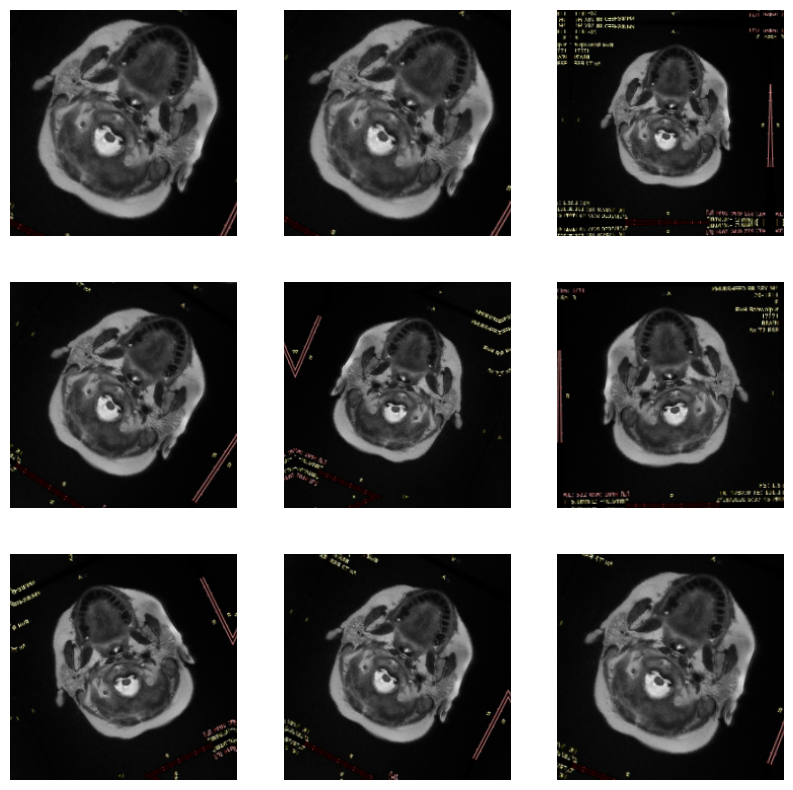

In [26]:
plt.figure(figsize=(10, 10))
for i, (images, _) in enumerate(train_data):
    if i == 1:  # Process only the first batch
        break
    for j in range(9):  # Assuming you still want 9 images
        augmented_images = data_augmentation(images)
        ax = plt.subplot(3, 3, j + 1)
        plt.imshow(augmented_images[0].numpy().astype("uint8"))
        plt.axis("off")


In [27]:
import tensorflow as tf
from tensorflow import keras
from keras import layers

inputs = keras.Input(shape=(224, 224, 3))
x = data_augmentation(inputs)
x = layers.Rescaling(1./255)(inputs)

x = layers.Conv2D(filters=16, kernel_size=5, activation="relu")(x)
#x = layers.MaxPooling2D(pool_size=3)(x)
x = layers.Conv2D(filters=64, kernel_size=5, activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D(pool_size=3)(x)

x = layers.Conv2D(filters=32, kernel_size=5, activation="relu")(x)
#x = layers.MaxPooling2D(pool_size=3)(x)
x = layers.Conv2D(filters=64, kernel_size=5, activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D(pool_size=3)(x)

x = layers.Conv2D(filters=128, kernel_size=5, activation="relu")(x)
#x = layers.MaxPooling2D(pool_size=3)(x)
x = layers.Conv2D(filters=256, kernel_size=5, activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D(pool_size=2)(x)

x = layers.Flatten()(x)
x = layers.Dropout(0.25)(x)
outputs = layers.Dense(2, activation="softmax")(x)
model = keras.Model(inputs=inputs, outputs=outputs)

In [28]:
model.summary()

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 rescaling_1 (Rescaling)     (None, 224, 224, 3)       0         
                                                                 
 conv2d_6 (Conv2D)           (None, 220, 220, 16)      1216      
                                                                 
 conv2d_7 (Conv2D)           (None, 216, 216, 64)      25664     
                                                                 
 batch_normalization_3 (Bat  (None, 216, 216, 64)      256       
 chNormalization)                                                
                                                                 
 max_pooling2d_3 (MaxPoolin  (None, 72, 72, 64)        0         
 g2D)                                                      

In [29]:
model.compile(optimizer="rmsprop",
 loss="binary_crossentropy",
 metrics=["accuracy"])


In [30]:
callbacks = [
 keras.callbacks.ModelCheckpoint(
 filepath="CNNFinal.keras",
 save_best_only=True,monitor="val_loss")]


In [31]:
history = model.fit(train_data,
                   validation_data = (val_data),
                    callbacks=callbacks,
                    epochs=20)

Epoch 1/20
147/147 [==============================] - 29s 183ms/step - loss: 0.9620 - accuracy: 0.6125 - val_loss: 1.6597 - val_accuracy: 0.5176
Epoch 2/20
147/147 [==============================] - 26s 177ms/step - loss: 0.6436 - accuracy: 0.6846 - val_loss: 0.6502 - val_accuracy: 0.6050
Epoch 3/20
147/147 [==============================] - 26s 178ms/step - loss: 0.5535 - accuracy: 0.7387 - val_loss: 0.5532 - val_accuracy: 0.7206
Epoch 4/20
147/147 [==============================] - 26s 177ms/step - loss: 0.4477 - accuracy: 0.7956 - val_loss: 0.6193 - val_accuracy: 0.6925
Epoch 5/20
147/147 [==============================] - 27s 184ms/step - loss: 0.3063 - accuracy: 0.8667 - val_loss: 0.3277 - val_accuracy: 0.8593
Epoch 6/20
147/147 [==============================] - 26s 180ms/step - loss: 0.1110 - accuracy: 0.9559 - val_loss: 0.4021 - val_accuracy: 0.8452
Epoch 7/20
147/147 [==============================] - 26s 178ms/step - loss: 0.0472 - accuracy: 0.9850 - val_loss: 0.0463 - val_ac

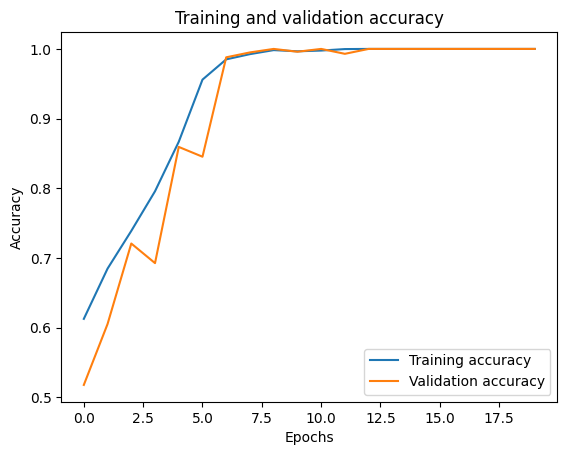

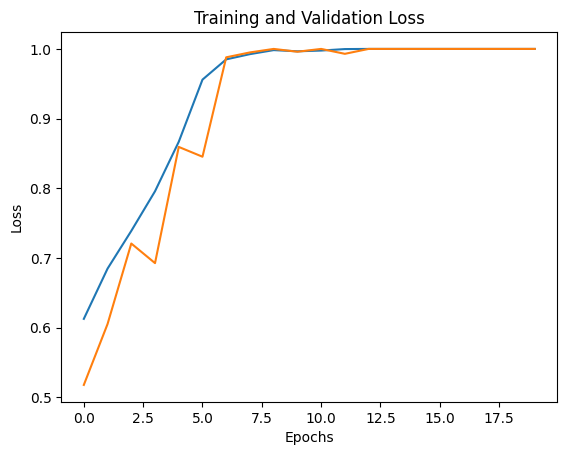

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.plot(history.history['accuracy'], label="Training accuracy")
plt.plot(history.history['val_accuracy'], label="Validation accuracy")
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()
# Plot using Seaborn

plt.plot(history.history['accuracy'], label="Training loss")
plt.plot(history.history['val_accuracy'], label="Validation loss")
#my_plot = sns.lineplot(data=history[["loss","validation_loss"]])
plt.xlabel('Epochs')
plt.ylabel('Loss')
#plt.legend(labels=["Training", "Validation"])
plt.title('Training and Validation Loss')
plt.show()

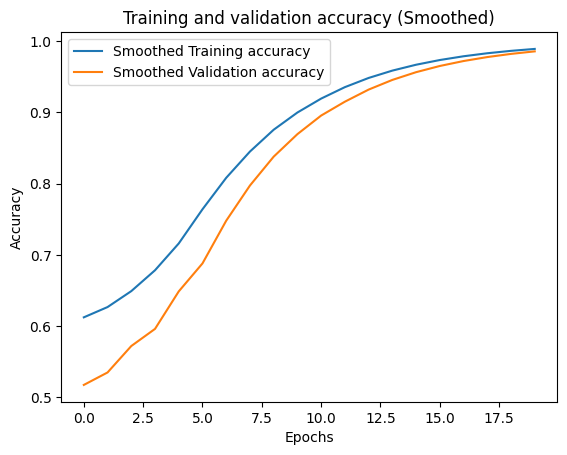

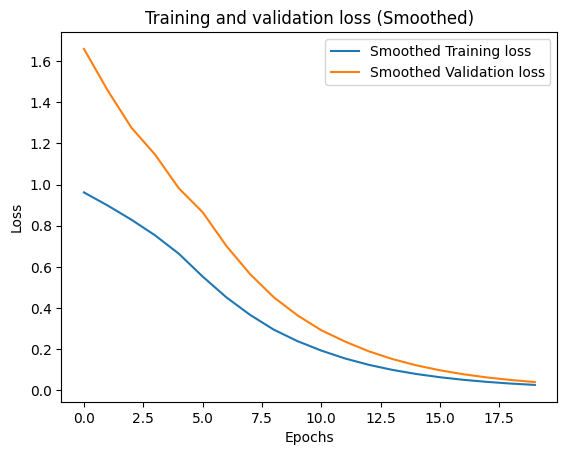

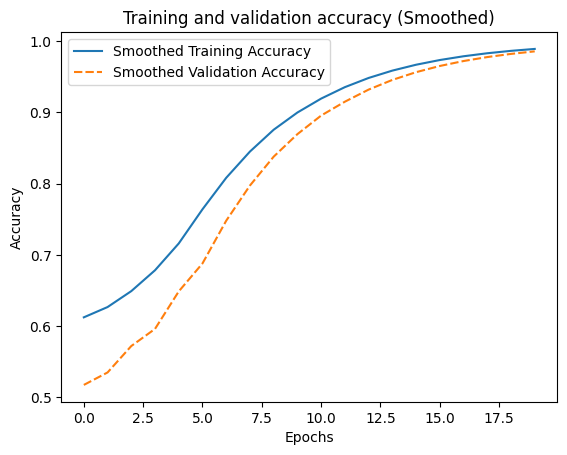

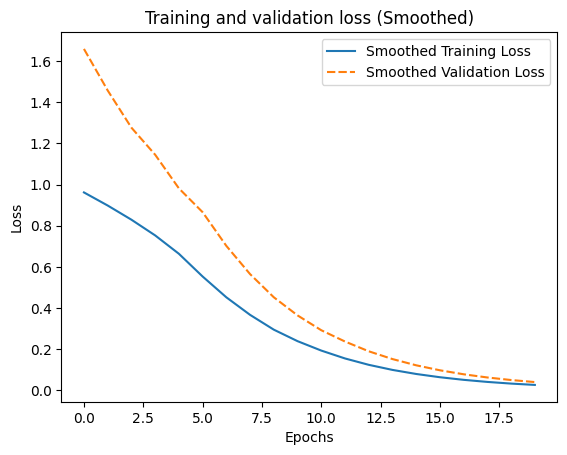

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define the smooth_curve function
def smooth_curve(points, factor=0.8):
    smoothed_points = []
    for point in points:
        if smoothed_points:
            previous = smoothed_points[-1]
            smoothed_points.append(previous * factor + point * (1 - factor))
        else:
            smoothed_points.append(point)
    return smoothed_points

# Smooth the accuracy and loss data
smoothed_acc = smooth_curve(history.history['accuracy'])
smoothed_val_acc = smooth_curve(history.history['val_accuracy'])
smoothed_loss = smooth_curve(history.history['loss'])
smoothed_val_loss = smooth_curve(history.history['val_loss'])

# Matplotlib plots for accuracy
plt.plot(smoothed_acc, label="Smoothed Training accuracy")
plt.plot(smoothed_val_acc, label="Smoothed Validation accuracy")
plt.title('Training and validation accuracy (Smoothed)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Matplotlib plots for loss
plt.plot(smoothed_loss, label="Smoothed Training loss")
plt.plot(smoothed_val_loss, label="Smoothed Validation loss")
plt.title('Training and validation loss (Smoothed)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Seaborn plots for accuracy
sns.lineplot(data={'Smoothed Training Accuracy': smoothed_acc, 'Smoothed Validation Accuracy': smoothed_val_acc})
plt.title('Training and validation accuracy (Smoothed)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Seaborn plots for loss
sns.lineplot(data={'Smoothed Training Loss': smoothed_loss, 'Smoothed Validation Loss': smoothed_val_loss})
plt.title('Training and validation loss (Smoothed)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


In [34]:
model.evaluate(imgs, labels)

32/32 [==============================] - 1s 19ms/step - loss: 0.0019 - accuracy: 0.9990


[0.0019497046014294028, 0.9990059733390808]

In [35]:
train_data.class_indices

{'High_Grade': 0, 'Low_Grade': 1}

In [38]:
import numpy as np
import pandas as pd

y_pred = model.predict(imgs, verbose=0)
y_pred.shape

(1006, 2)

In [39]:
from sklearn.metrics import confusion_matrix
c_matrix = confusion_matrix(np.argmax(labels, axis=1), np.argmax(y_pred, axis=1))

import seaborn as sns
def confusion_matrix(confusion_matrix, class_names, figsize = (15,7), fontsize=14):
    """Prints a confusion matrix, as returned by sklearn.metrics.confusion_matrix, as a heatmap.

    Arguments
    ---------
    confusion_matrix: numpy.ndarray
        The numpy.ndarray object returned from a call to sklearn.metrics.confusion_matrix.
        Similarly constructed ndarrays can also be used.
    class_names: list
        An ordered list of class names, in the order they index the given confusion matrix.
    figsize: tuple
        A 2-long tuple, the first value determining the horizontal size of the ouputted figure,
        the second determining the vertical size. Defaults to (10,7).
    fontsize: int
        Font size for axes labels. Defaults to 14.
    """
    df_cm = pd.DataFrame(
        confusion_matrix, index=class_names, columns=class_names,
    )
    fig = plt.figure(figsize=figsize)
    try:
        heatmap = sns.heatmap(df_cm, annot=True, fmt="d")
    except ValueError:
        raise ValueError("Confusion matrix values must be integers.")
    heatmap.yaxis.set_ticklabels(heatmap.yaxis.get_ticklabels(), rotation=0, ha='right', fontsize=fontsize)
    heatmap.xaxis.set_ticklabels(heatmap.xaxis.get_ticklabels(), rotation=45, ha='right', fontsize=fontsize)
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

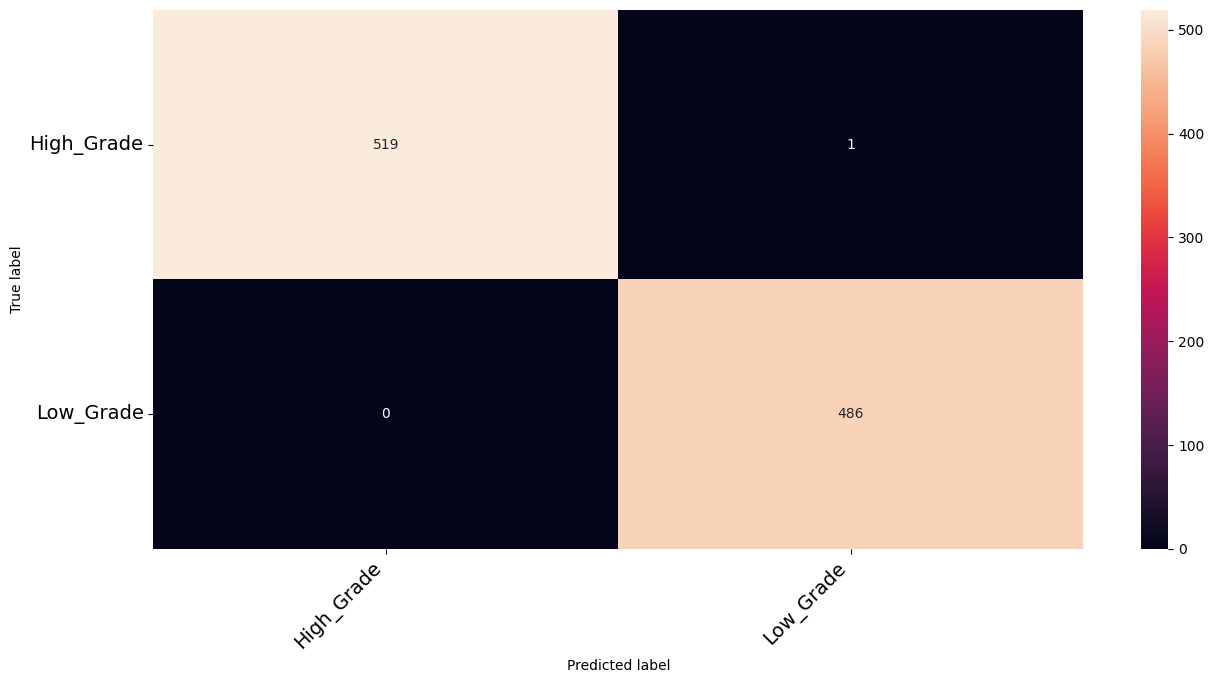

In [40]:
class_names = test_data.class_indices.keys()
confusion_matrix(c_matrix, class_names, figsize = (15,7), fontsize=14)

In [41]:
# From categorical outputs to discrete values

y_pred_ = [np.argmax(y) for y in y_pred]
y_test_ = [np.argmax(y) for y in labels]

from sklearn.metrics import classification_report
print(classification_report(y_test_, y_pred_))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       520
           1       1.00      1.00      1.00       486

    accuracy                           1.00      1006
   macro avg       1.00      1.00      1.00      1006
weighted avg       1.00      1.00      1.00      1006

